In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [32]:
df = pd.read_parquet("../../data/processed/btc_features_1m.parquet")

In [33]:
df = df.dropna()

In [34]:
df.head()

,timestamp,price_measurement_timestamp,ctx_recorded_at_ms,spot_price,perp_price,spot_microprice,perp_microprice,basis_dollar,basis_bps,midprice_basis,...,microprice_3x_basis,funding_rate,open_interest,oracle_price,mark_price,ctx_mid_price,premium,impact_bid_price,impact_ask_price,day_notional_volume
6,2026-03-30 17:11:00+00:00,1774890719970,1.774891e+12,67213.5,67200.5,67213.281775,67200.591120,-13.000000,-1.934135,-13.000000,...,-12.691389,-0.000016,27800.57864,67238.0,67200.0,67200.5,-0.000550,67200.0,67201.0,2.120494e+09
7,2026-03-30 17:12:00+00:00,1774890779987,1.774891e+12,67215.5,67204.5,67215.278773,67204.124497,-10.428489,-1.551501,-10.428489,...,-10.612345,-0.000016,27804.71532,67253.0,67210.0,67206.5,-0.000684,67204.8,67207.0,2.120924e+09
8,2026-03-30 17:13:00+00:00,1774890839946,1.774891e+12,67169.5,67158.5,67169.252400,67158.479594,-11.000301,-1.637693,-11.000301,...,-10.769543,-0.000017,27808.35850,67202.0,67158.0,67150.5,-0.000759,67150.0,67151.0,2.122518e+09
9,2026-03-30 17:14:00+00:00,1774890899979,1.774891e+12,67158.5,67147.5,67158.373973,67147.392746,-11.000000,-1.637916,-11.000000,...,-10.945512,-0.000017,27807.76898,67189.0,67147.0,67147.5,-0.000610,67147.0,67148.0,2.123381e+09
10,2026-03-30 17:15:00+00:00,1774890959951,1.774891e+12,67122.5,67117.5,67122.119372,67117.105396,-5.000000,-0.744907,-5.000000,...,-5.022224,-0.000017,27800.90406,67162.0,67124.0,67117.5,-0.000655,67116.7,67118.0,2.125089e+09


In [35]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

In [36]:
df.size

52626

In [37]:
print("rows:", len(df))
print("start:", df["timestamp"].min())
print("end:  ", df["timestamp"].max())
print("minutes covered:", (df["timestamp"].max() - df["timestamp"].min()) / pd.Timedelta(minutes=1))
print("days covered:", (df["timestamp"].max() - df["timestamp"].min()) / pd.Timedelta(days=1))

rows: 2506
start: 2026-03-30 17:11:00+00:00
end:   2026-04-01 11:00:00+00:00
minutes covered: 2509.0
days covered: 1.742361111111111


In [38]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price_measurement_timestamp,2506.0,1.774966e+12,4.346044e+07,1.774891e+12,1.774928e+12,1.774966e+12,1.775004e+12,1.775041e+12
ctx_recorded_at_ms,2506.0,1.774966e+12,4.346044e+07,1.774891e+12,1.774928e+12,1.774966e+12,1.775004e+12,1.775041e+12
spot_price,2506.0,6.752545e+04,7.391825e+02,6.600750e+04,6.679712e+04,6.763100e+04,6.809150e+04,6.921150e+04
perp_price,2506.0,6.752424e+04,7.350412e+02,6.601150e+04,6.679850e+04,6.763050e+04,6.808250e+04,6.920050e+04
spot_microprice,2506.0,6.752543e+04,7.392394e+02,6.600737e+04,6.679669e+04,6.763053e+04,6.809170e+04,6.921188e+04
perp_microprice,2506.0,6.752423e+04,7.350348e+02,6.601147e+04,6.679906e+04,6.763050e+04,6.808252e+04,6.920088e+04
basis_dollar,2506.0,-1.217673e+00,1.023299e+01,-6.652301e+01,-6.469192e+00,-4.716439e-04,5.000000e+00,3.751234e+01
basis_bps,2506.0,-1.736585e-01,1.507416e+00,-9.978402e+00,-9.541209e-01,-6.893146e-05,7.427612e-01,5.490884e+00
midprice_basis,2506.0,-1.217673e+00,1.023299e+01,-6.652301e+01,-6.469192e+00,-4.716439e-04,5.000000e+00,3.751234e+01
microprice_1p5x_basis,2506.0,-1.219247e+00,1.013546e+01,-6.857755e+01,-6.425836e+00,-2.897671e-01,5.037519e+00,3.776443e+01


In [39]:
print("duplicate timestamps:", df["timestamp"].duplicated().sum())

df["dt_min"] = df["timestamp"].diff().dt.total_seconds() / 60
df["dt_min"].describe()

duplicate timestamps: 0


count    2505.000000
mean        1.001597
std         0.048925
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: dt_min, dtype: float64

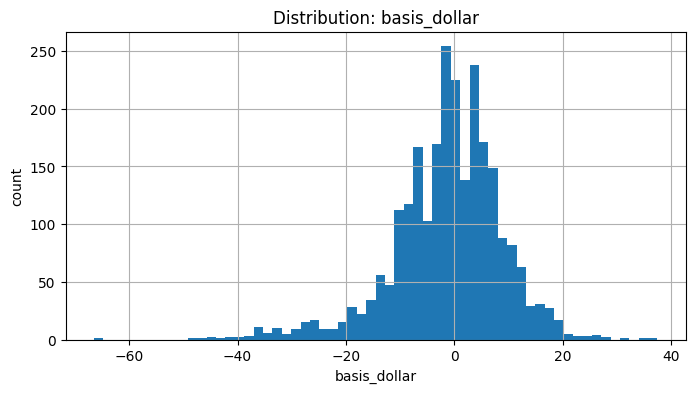

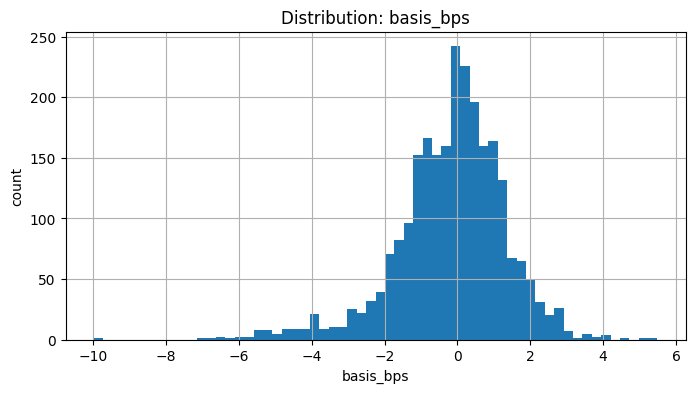

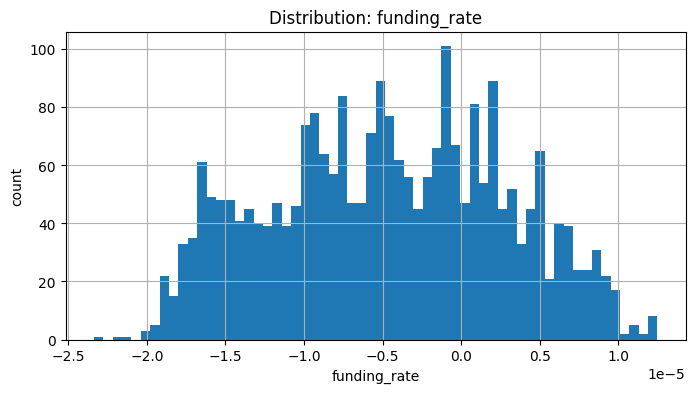

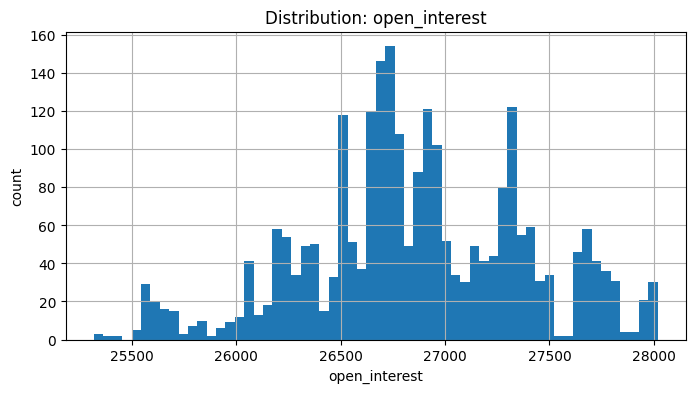

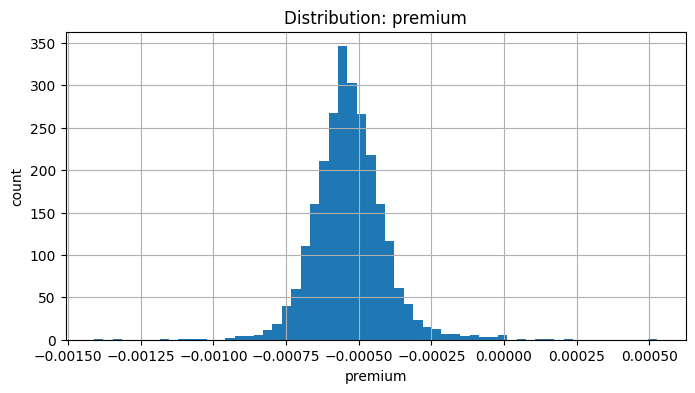

In [40]:
cols_to_plot = ["basis_dollar", "basis_bps", "funding_rate", "open_interest", "premium"]

for col in cols_to_plot:
    plt.figure(figsize=(8, 4))
    df[col].dropna().hist(bins=60)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

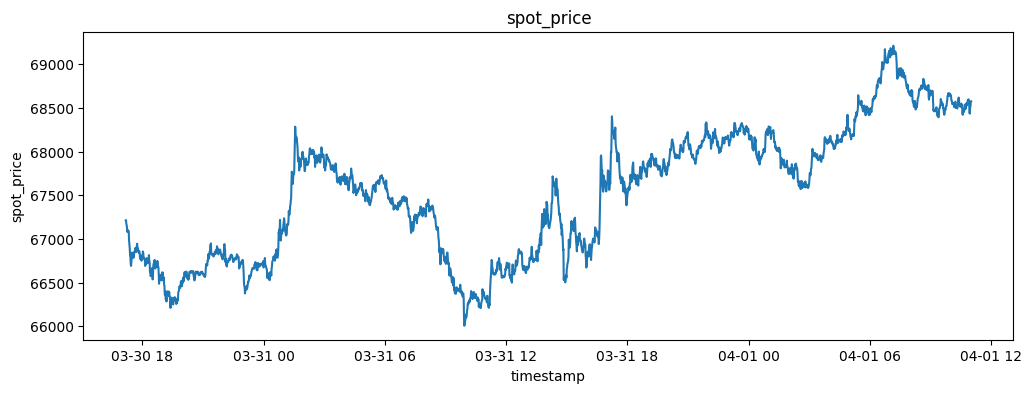

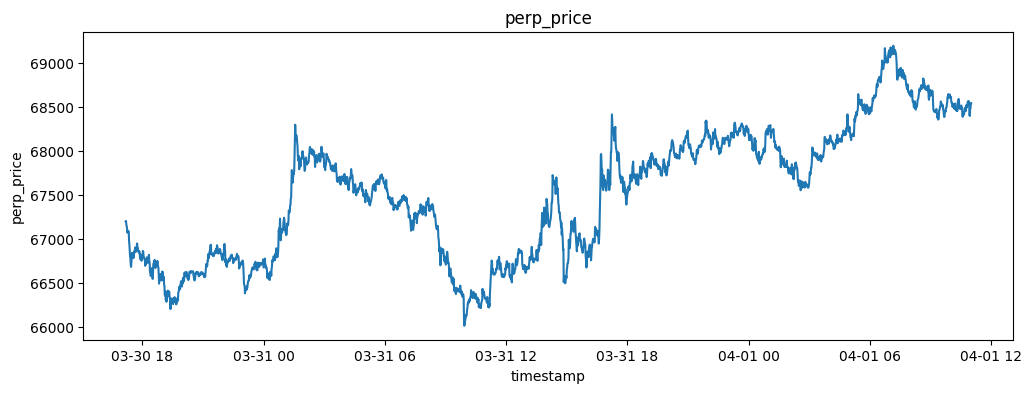

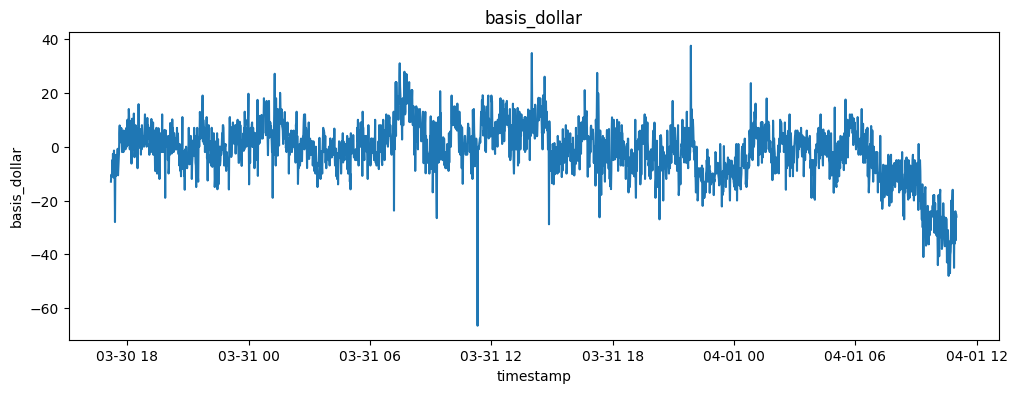

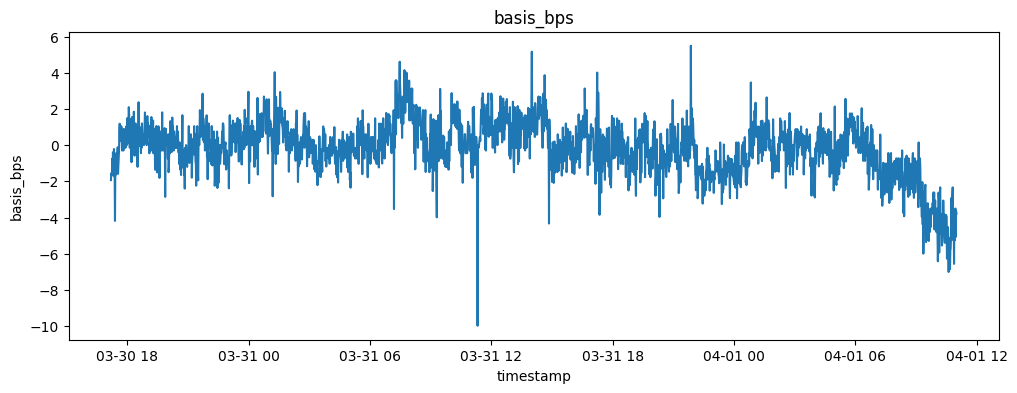

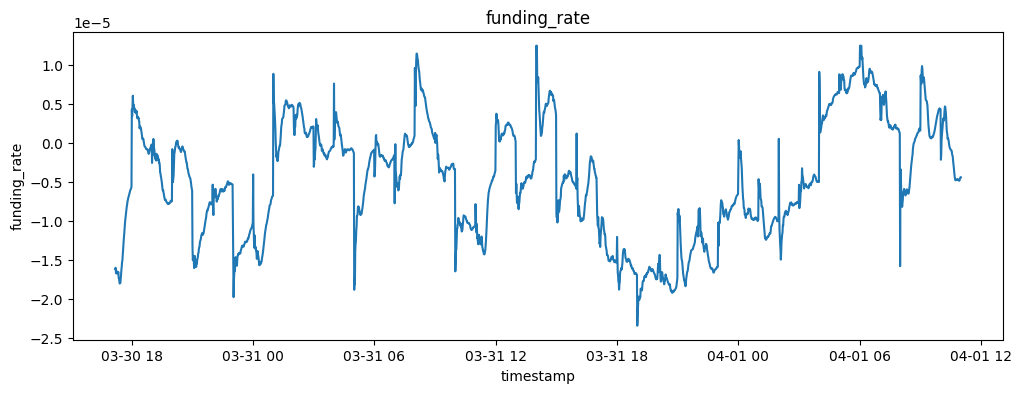

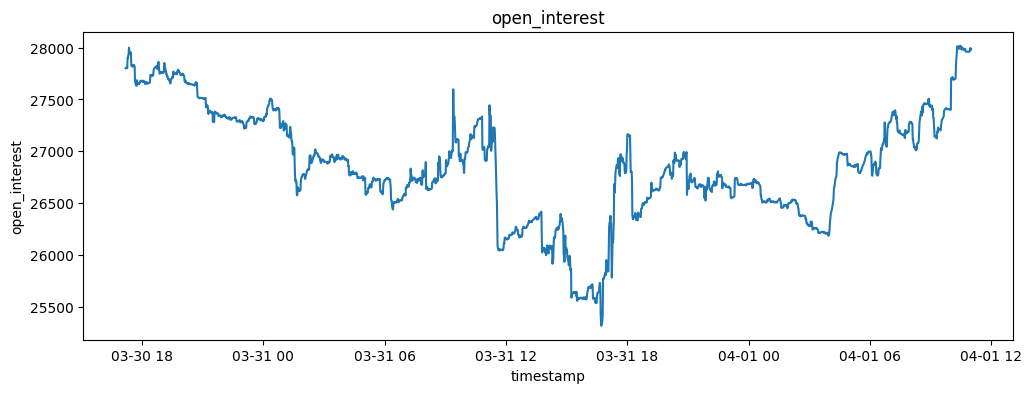

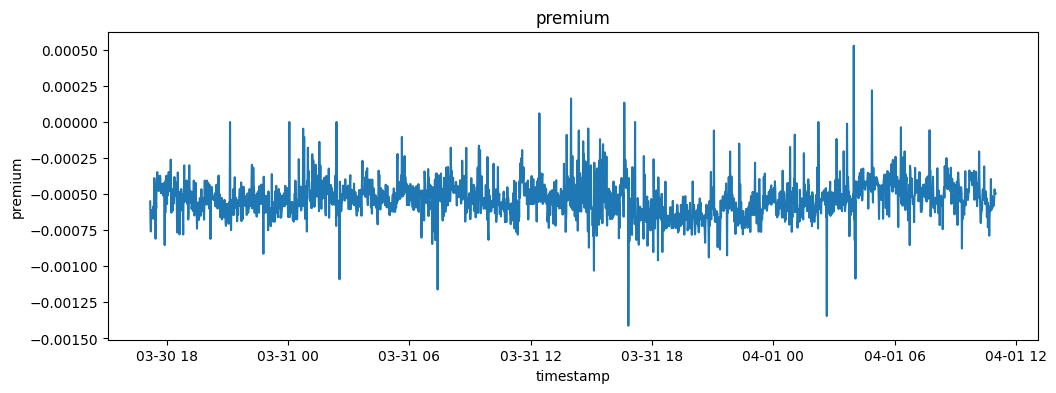

In [41]:
time_series_cols = ["spot_price", "perp_price", "basis_dollar", "basis_bps","funding_rate", "open_interest", "premium"]

for col in time_series_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df["timestamp"], df[col])
    plt.title(col)
    plt.xlabel("timestamp")
    plt.ylabel(col)
    plt.show()

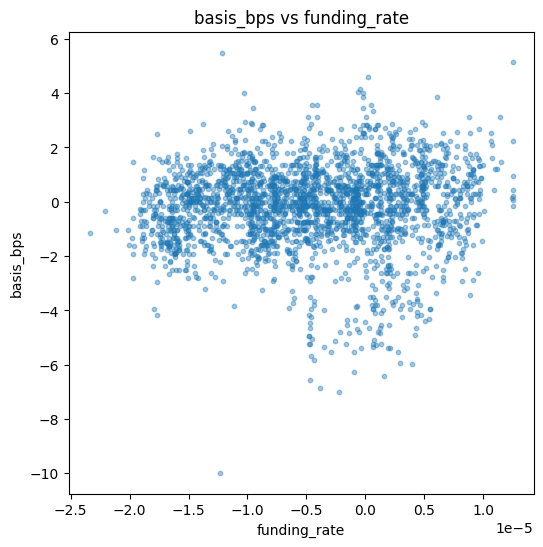

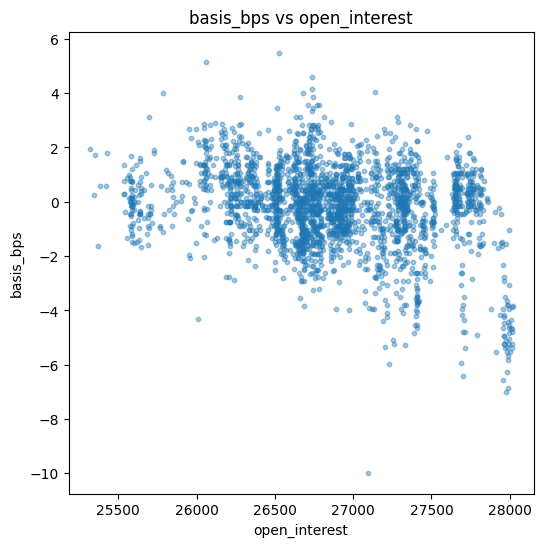

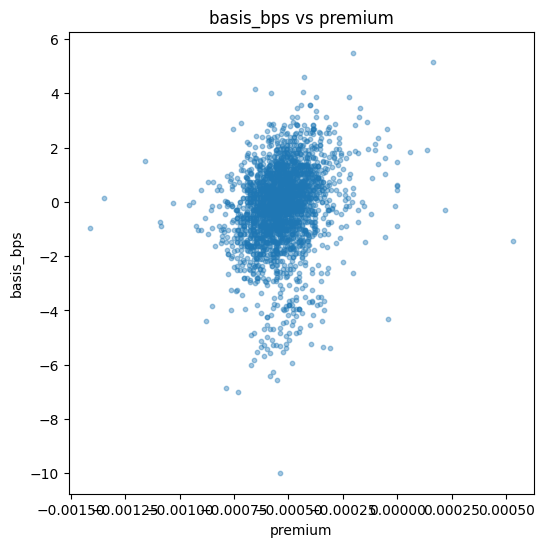

In [42]:
pairs = [
    ("funding_rate", "basis_bps"),
    ("open_interest", "basis_bps"),
    ("premium", "basis_bps"),
]

for x, y in pairs:
    if x in df.columns and y in df.columns:
        temp = df[[x, y]].dropna()
        if len(temp) > 5000:
            temp = temp.sample(5000, random_state=0)
        plt.figure(figsize=(6, 6))
        plt.scatter(temp[x], temp[y], alpha=0.4, s=10)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{y} vs {x}")
        plt.show()

In [43]:
corr_cols = [
        "basis_dollar", "basis_bps", "funding_rate", "open_interest", "premium",
        "spot_price", "perp_price", "mark_price", "oracle_price", "ctx_mid_price",
        "day_notional_volume"
]

corr = df[corr_cols].corr()

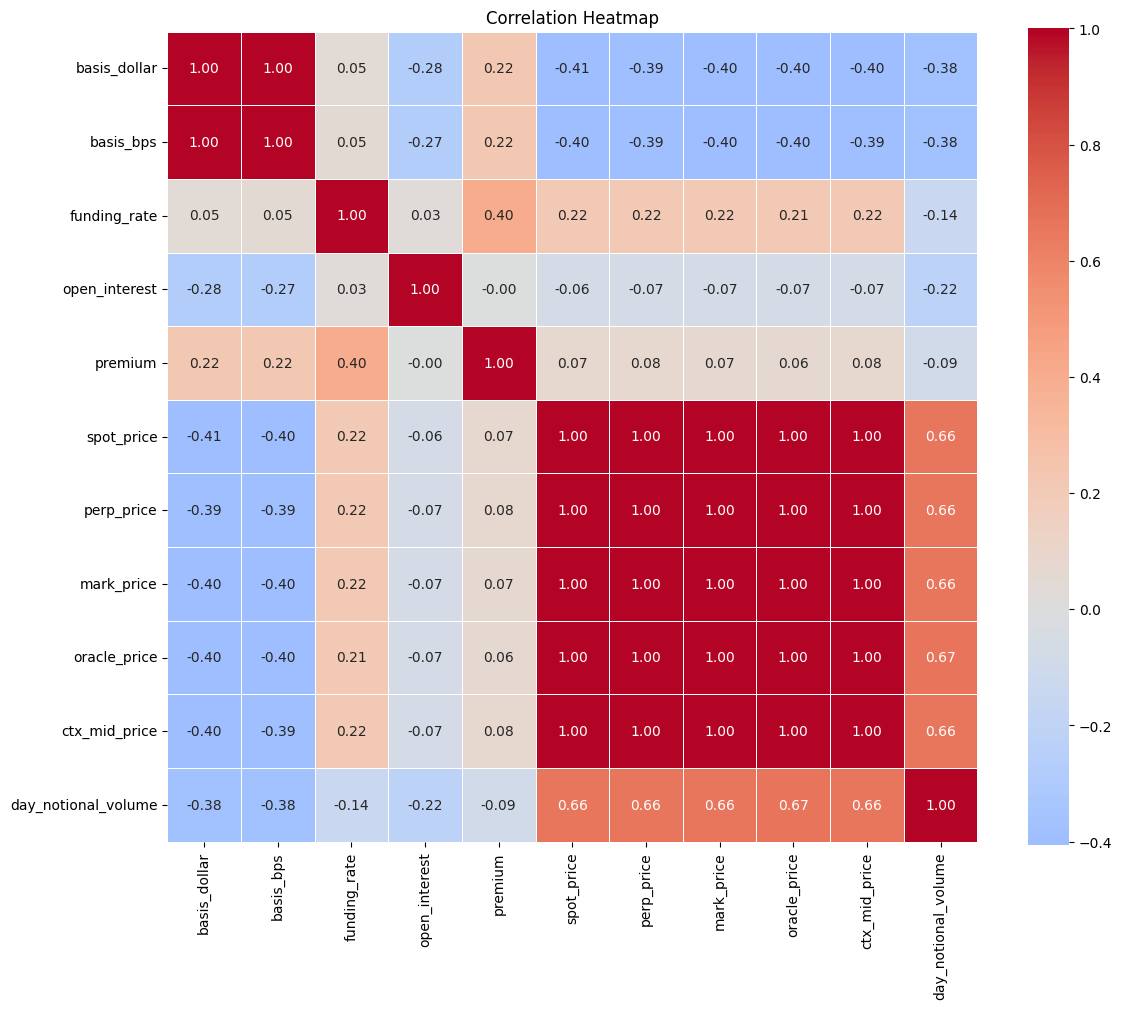

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [45]:
# safer log transform for OI
df["log_open_interest"] = np.log(df["open_interest"].replace(0, np.nan))

# returns
df["spot_ret_1m"] = np.log(df["spot_price"]).diff()

df["perp_ret_1m"] = np.log(df["perp_price"]).diff()

# OI changes
df["d_open_interest"] = df["open_interest"].diff()
df["d_log_open_interest"] = df["log_open_interest"].diff()

# basis changes
df["basis_bps_change_1m"] = df["basis_bps"].diff()

# rolling realized vol
df["spot_rv_15m"] = df["spot_ret_1m"].rolling(15).std()

# future targets
for h in [1, 5, 15, 60]:
    df[f"future_basis_change_{h}m"] = df["basis_bps"].shift(-h) - df["basis_bps"]
    df[f"future_abs_basis_change_{h}m"] = df[f"future_basis_change_{h}m"].abs()

df.head()

,timestamp,price_measurement_timestamp,ctx_recorded_at_ms,spot_price,perp_price,spot_microprice,perp_microprice,basis_dollar,basis_bps,midprice_basis,...,basis_bps_change_1m,spot_rv_15m,future_basis_change_1m,future_abs_basis_change_1m,future_basis_change_5m,future_abs_basis_change_5m,future_basis_change_15m,future_abs_basis_change_15m,future_basis_change_60m,future_abs_basis_change_60m
0,2026-03-30 17:11:00+00:00,1774890719970,1.774891e+12,67213.5,67200.5,67213.281775,67200.591120,-13.000000,-1.934135,-13.000000,...,NaN,NaN,0.382635,0.382635,0.592464,0.592464,1.479236,1.479236,2.233772,2.233772
1,2026-03-30 17:12:00+00:00,1774890779987,1.774891e+12,67215.5,67204.5,67215.278773,67204.124497,-10.428489,-1.551501,-10.428489,...,0.382635,NaN,-0.086192,0.086192,1.155151,1.155151,0.052072,0.052072,3.108954,3.108954
2,2026-03-30 17:13:00+00:00,1774890839946,1.774891e+12,67169.5,67158.5,67169.252400,67158.479594,-11.000301,-1.637693,-11.000301,...,-0.086192,NaN,-0.000223,0.000223,0.107716,0.107716,0.129279,0.129279,1.937297,1.937297
3,2026-03-30 17:14:00+00:00,1774890899979,1.774891e+12,67158.5,67147.5,67158.373973,67147.392746,-11.000000,-1.637916,-11.000000,...,-0.000223,NaN,0.893010,0.893010,-0.070630,0.070630,0.445859,0.445859,2.237414,2.237414
4,2026-03-30 17:15:00+00:00,1774890959951,1.774891e+12,67122.5,67117.5,67122.119372,67117.105396,-5.000000,-0.744907,-5.000000,...,0.893010,NaN,-0.596765,0.596765,0.529792,0.529792,0.040065,0.040065,1.344272,1.344272


In [46]:
feature_cols = [
    c for c in [
        "basis_bps", "basis_bps_change_1m",
        "funding_rate", "open_interest", "log_open_interest",
        "d_open_interest", "d_log_open_interest",
        "spot_ret_1m", "perp_ret_1m", "spot_rv_15m",
        "future_basis_change_1m", "future_basis_change_5m",
        "future_basis_change_15m", "future_basis_change_60m"
    ] if c in df.columns
]

df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
basis_bps,2506.0,-0.173659,1.507416,-9.978402,-0.954121,-0.000069,0.742761,5.490884
basis_bps_change_1m,2505.0,-0.000743,1.141155,-9.907592,-0.652643,0.001010,0.687473,9.722772
funding_rate,2506.0,-0.000005,0.000007,-0.000023,-0.000010,-0.000005,0.000001,0.000013
open_interest,2506.0,26858.474612,531.565629,25317.780540,26533.486055,26815.016210,27275.215410,28018.248020
log_open_interest,2506.0,10.198140,0.019827,10.139262,10.186163,10.196717,10.213734,10.240611
d_open_interest,2505.0,0.072499,40.592827,-412.408800,-4.170800,0.441040,5.568580,597.219020
d_log_open_interest,2505.0,0.000003,0.001519,-0.015397,-0.000154,0.000016,0.000207,0.021877
spot_ret_1m,2505.0,0.000008,0.000664,-0.005277,-0.000334,-0.000015,0.000338,0.004381
perp_ret_1m,2505.0,0.000008,0.000685,-0.005652,-0.000353,-0.000015,0.000346,0.004498
spot_rv_15m,2491.0,0.000608,0.000261,0.000164,0.000437,0.000558,0.000702,0.002069


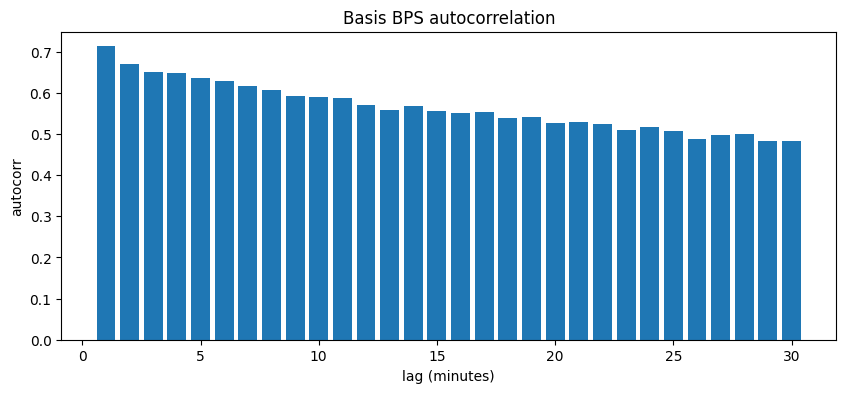

In [47]:
max_lag = 30
acf_vals = [df["basis_bps"].autocorr(lag=i) for i in range(1, max_lag + 1)]

plt.figure(figsize=(10, 4))
plt.bar(range(1, max_lag + 1), acf_vals)
plt.title("Basis BPS autocorrelation")
plt.xlabel("lag (minutes)")
plt.ylabel("autocorr")
plt.show()

In [51]:
temp = df[["basis_bps"]].dropna().copy()
temp["basis_bps_lag1"] = temp["basis_bps"].shift(1)
temp = temp.dropna()

X = sm.add_constant(temp["basis_bps_lag1"])
y = temp["basis_bps"]

ar1 = sm.OLS(y, X).fit()
phi = ar1.params["basis_bps_lag1"]

print(ar1.summary())

                            OLS Regression Results                            
Dep. Variable:              basis_bps   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     2591.
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:55:29   Log-Likelihood:                -3691.9
No. Observations:                2505   AIC:                             7388.
Df Residuals:                    2503   BIC:                             7399.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0500      0.021     -2.

In [52]:
if 0 < abs(phi) < 1:
    half_life = -np.log(2) / np.log(abs(phi))
    print("Estimated half-life (minutes):", half_life)
else:
    print("Half-life not well-defined because |phi| is not between 0 and 1.")

Estimated half-life (minutes): 2.055799629637887


In [53]:
basis_series = df["basis_bps"].dropna()

if len(basis_series) > 20:
    adf_result = adfuller(basis_series)
    print("ADF statistic:", adf_result[0])
    print("p-value:", adf_result[1])
    print("critical values:", adf_result[4])
else:
    print("Not enough data for ADF test.")

ADF statistic: -3.2596799708061597
p-value: 0.016779835305365226
critical values: {'1%': -3.4329799947351503, '5%': -2.862701915447137, '10%': -2.5673885329713495}


## Interpretation:

- Basis looks to be a stationary mean reverting process (need more data to be sure)


### Tests:

- high funding vs low funding impacts
- rising OI vs falling OI periods



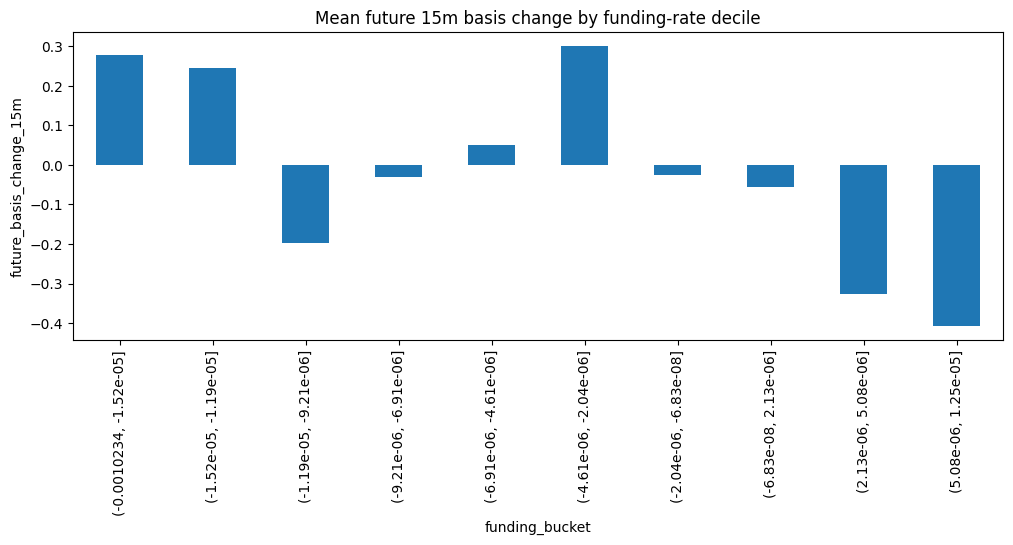

In [54]:
temp = df[["funding_rate", "future_basis_change_15m"]].dropna().copy()
temp["funding_bucket"] = pd.qcut(temp["funding_rate"], q=10, duplicates="drop")
bucketed = temp.groupby("funding_bucket", observed=False)["future_basis_change_15m"].mean()

plt.figure(figsize=(12, 4))
bucketed.plot(kind="bar")
plt.title("Mean future 15m basis change by funding-rate decile")
plt.ylabel("future_basis_change_15m")
plt.show()

In [55]:
bucketed

funding_bucket
(-0.0010234, -1.52e-05]    0.278766
(-1.52e-05, -1.19e-05]     0.245165
(-1.19e-05, -9.21e-06]    -0.196946
(-9.21e-06, -6.91e-06]    -0.031880
(-6.91e-06, -4.61e-06]     0.050334
(-4.61e-06, -2.04e-06]     0.300725
(-2.04e-06, -6.83e-08]    -0.024473
(-6.83e-08, 2.13e-06]     -0.056700
(2.13e-06, 5.08e-06]      -0.327305
(5.08e-06, 1.25e-05]      -0.407348
Name: future_basis_change_15m, dtype: float64

## Interepretation

- Low funding tends to be followed by basis rising, and high funding tends to be followed by basis falling

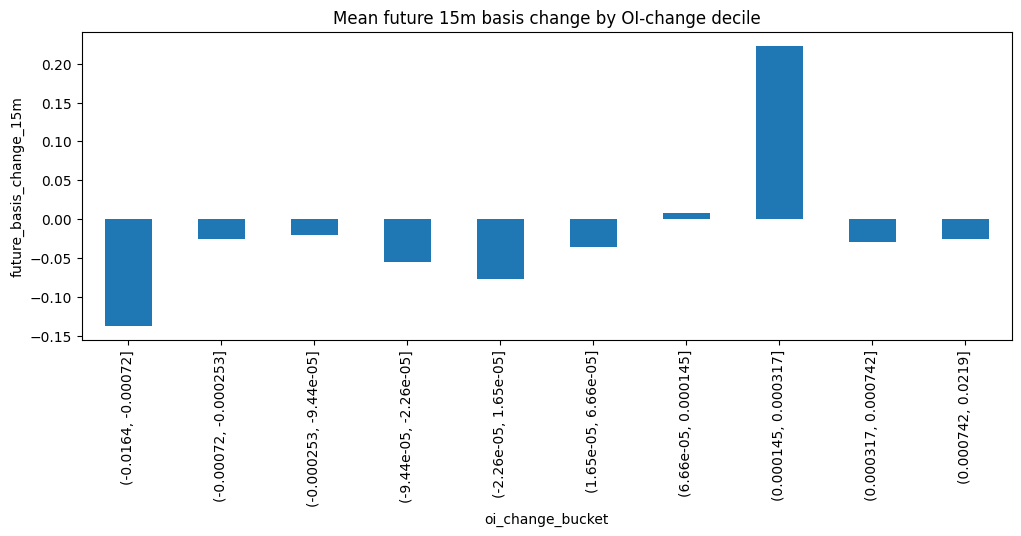

In [56]:
temp = df[["d_log_open_interest", "future_basis_change_15m"]].dropna().copy()
temp["oi_change_bucket"] = pd.qcut(temp["d_log_open_interest"], q=10, duplicates="drop")
bucketed = temp.groupby("oi_change_bucket", observed=False)["future_basis_change_15m"].mean()

plt.figure(figsize=(12, 4))
bucketed.plot(kind="bar")
plt.title("Mean future 15m basis change by OI-change decile")
plt.ylabel("future_basis_change_15m")
plt.show()

In [57]:
bucketed

oi_change_bucket
(-0.0164, -0.00072]      -0.137115
(-0.00072, -0.000253]    -0.025933
(-0.000253, -9.44e-05]   -0.019855
(-9.44e-05, -2.26e-05]   -0.054627
(-2.26e-05, 1.65e-05]    -0.076920
(1.65e-05, 6.66e-05]     -0.035963
(6.66e-05, 0.000145]      0.008384
(0.000145, 0.000317]      0.223054
(0.000317, 0.000742]     -0.029847
(0.000742, 0.0219]       -0.025661
Name: future_basis_change_15m, dtype: float64

## Interpretation

- OI change alone does not show a strong, stable, monotonic relationship with future 15-minute basis change in this sample.

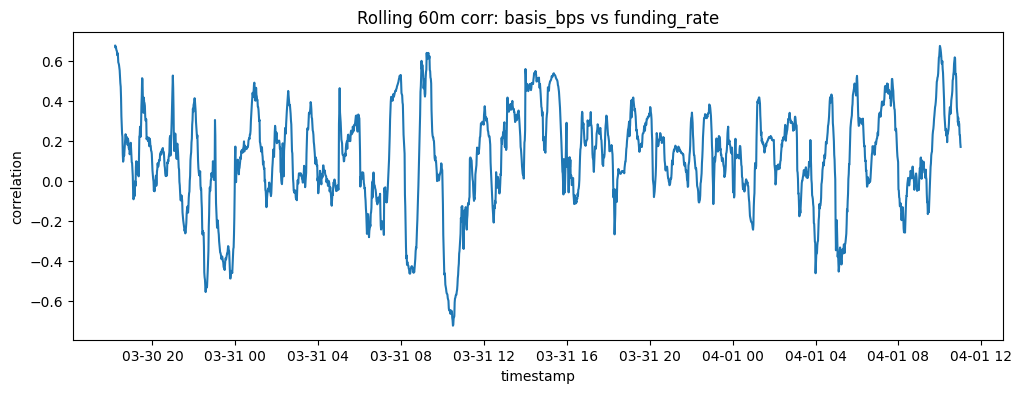

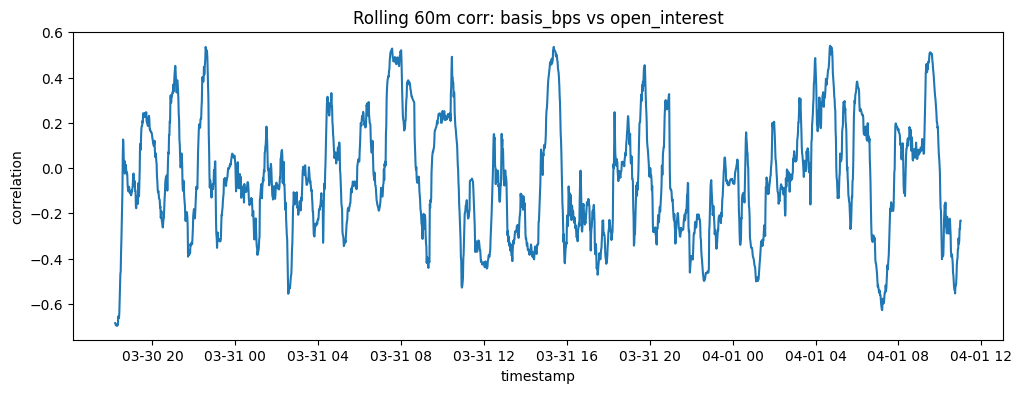

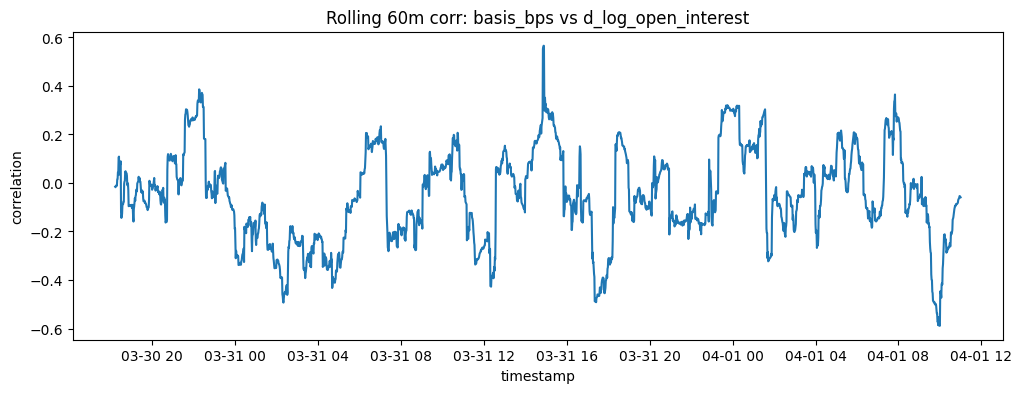

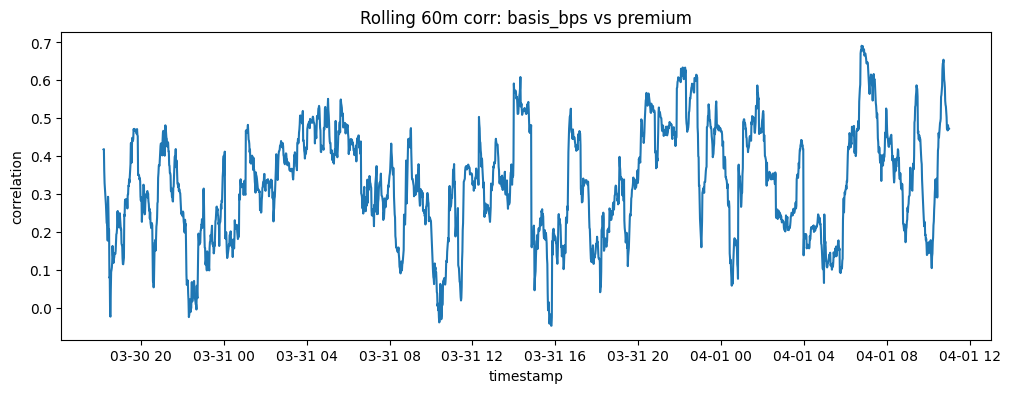

In [58]:
window = 60  # 60 minutes

for x in ["funding_rate", "open_interest", "d_log_open_interest", "premium"]:
    rolling_corr = df["basis_bps"].rolling(window).corr(df[x])

    plt.figure(figsize=(12, 4))
    plt.plot(df["timestamp"], rolling_corr)
    plt.title(f"Rolling {window}m corr: basis_bps vs {x}")
    plt.xlabel("timestamp")
    plt.ylabel("correlation")
    plt.show()

In [59]:
reg_cols = ["basis_bps", "funding_rate", "premium", "log_open_interest"]
reg_cols = [c for c in reg_cols if c in df.columns]

temp = df[reg_cols].dropna().copy()

X = temp.drop(columns=["basis_bps"])
X = sm.add_constant(X)
y = temp["basis_bps"]

model_contemp = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model_contemp.summary())

                            OLS Regression Results                            
Dep. Variable:              basis_bps   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     28.89
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           2.33e-18
Time:                        09:13:31   Log-Likelihood:                -4417.4
No. Observations:                2506   AIC:                             8843.
Df Residuals:                    2502   BIC:                             8866.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               210.6084     37.21

In [60]:
reg_cols = [
    "future_basis_change_15m",
    "basis_bps",
    "funding_rate",
    "d_log_open_interest",
    "premium",
    "spot_ret_1m",
    "spot_rv_15m"
]
reg_cols = [c for c in reg_cols if c in df.columns]

temp = df[reg_cols].dropna().copy()

X = temp.drop(columns=["future_basis_change_15m"])
X = sm.add_constant(X)
y = temp["future_basis_change_15m"]

model_pred_15m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 15})
print(model_pred_15m.summary())

                               OLS Regression Results                              
Dep. Variable:     future_basis_change_15m   R-squared:                       0.225
Model:                                 OLS   Adj. R-squared:                  0.223
Method:                      Least Squares   F-statistic:                     27.07
Date:                     Wed, 01 Apr 2026   Prob (F-statistic):           2.10e-31
Time:                             09:14:01   Log-Likelihood:                -4029.6
No. Observations:                     2476   AIC:                             8073.
Df Residuals:                         2469   BIC:                             8114.
Df Model:                                6                                         
Covariance Type:                       HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [61]:
results = []

for h in [1, 5, 15, 60]:
    target = f"future_basis_change_{h}m"
    reg_cols = [
        target,
        "basis_bps",
        "funding_rate",
        "d_log_open_interest",
        "premium",
        "spot_ret_1m",
        "spot_rv_15m"
    ]
    reg_cols = [c for c in reg_cols if c in df.columns]

    temp = df[reg_cols].dropna().copy()
    if len(temp) < 30:
        continue

    X = sm.add_constant(temp.drop(columns=[target]))
    y = temp[target]

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": min(h, 20)})

    for var in X.columns:
        if var == "const":
            continue
        results.append({
            "horizon_m": h,
            "variable": var,
            "coef": model.params[var],
            "tstat": model.tvalues[var],
            "pvalue": model.pvalues[var],
            "nobs": int(model.nobs),
            "r2": model.rsquared
        })

results_df = pd.DataFrame(results)
results_df.sort_values(["variable", "horizon_m"])

,horizon_m,variable,coef,tstat,pvalue,nobs,r2
0,1,basis_bps,-0.282176,-12.158241,5.186345e-34,2490,0.157051
6,5,basis_bps,-0.349193,-10.169665,2.708397e-24,2486,0.195207
12,15,basis_bps,-0.412198,-7.055009,1.725901e-12,2476,0.224714
18,60,basis_bps,-0.548940,-5.745673,9.155590e-09,2431,0.258707
2,1,d_log_open_interest,-22.694397,-1.329883,1.835570e-01,2490,0.157051
8,5,d_log_open_interest,8.356974,0.491584,6.230136e-01,2486,0.195207
14,15,d_log_open_interest,-10.714644,-0.551638,5.811962e-01,2476,0.224714
20,60,d_log_open_interest,-41.283453,-2.150614,3.150671e-02,2431,0.258707
1,1,funding_rate,1404.731845,0.484802,6.278171e-01,2490,0.157051
7,5,funding_rate,-4259.495859,-0.902474,3.668051e-01,2486,0.195207


## Interpretations

- Basis is strongly mean-reverting
- The mean-reversion effect gets stronger as the horizon increases from 1m to 60m
- Premium contains predictive information about future basis compression, especially at short horizons (premium is essentially a derivative of basis so this is to be expected)